In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
import matplotlib
import copy

from alter_surf.hamiltonian_DLKK import create_H_DLKK_3D_MF
from alter_surf.mean_field import hartree_fock, total_energy

# for observables
from blochK.plotting import plot_FS, plot_bandstruc
from blochK.plotting.utils import sample_square, extent
from blochK.observable import exp_value_O,conductivity_orbital_resolved, local_dos_QPI


from alter_surf.utils3D import projector2layer


In [2]:
Hparam0 = dict(len_z=20,delta=0.8, tp=0.5, tz=1, U=8, filling=0.5+1e-2, PBC= False)
H_DLKK = create_H_DLKK_3D_MF(param=Hparam0) #set up Hamiltonian with fixed len_z because it defines n_orbitals

MF_parameters = dict(n_steps=6, Lq=40, tol_mdiff=1e-4,mixing_proportion=0.1,adjust_learning_rate=False)

initial_parameters = dict(initial_mAF=(-1)**np.arange(Hparam0['len_z'])/4,
                          initial_mF =np.ones(Hparam0['len_z']) * 0,
                          initial_n=Hparam0['filling']*np.ones(Hparam0['len_z'])*2)


mAFs, mFs, ns, fermi_energys = hartree_fock(H_DLKK,initial_parameters, **MF_parameters)

H_DLKK.update_params(dict(mAF=mAFs[-1],mF=mFs[-1],ns=ns[-1],mu=fermi_energys[-1]))



Avg:-0.00, Stag. avg:0.82, diff: 0.006074: 100%|██████████| 6/6 [00:11<00:00,  1.93s/it]


Checking the convergence of the MF simualtion 

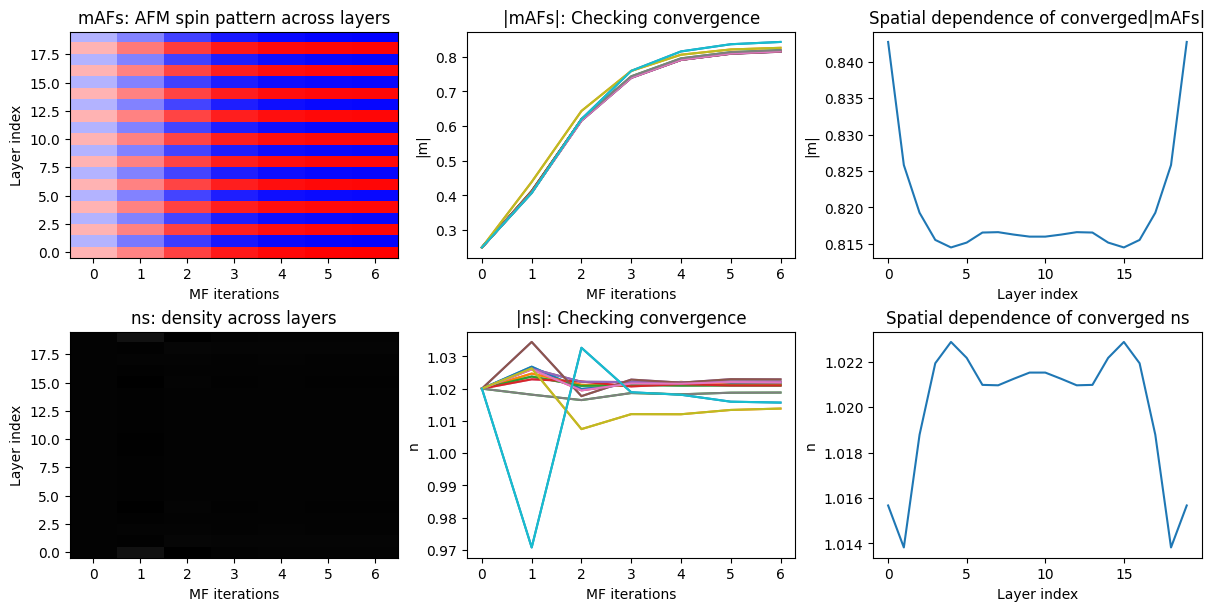

In [3]:
fig, axs = plt.subplots(2,3, figsize=(12,6), constrained_layout=True)

#plot the AF magnatization 
axs[0,0].set_title('mAFs: AFM spin pattern across layers')
axs[0,0].set_xlabel('MF iterations')
axs[0,0].set_ylabel('Layer index')
axs[0,0].imshow(mAFs.T, aspect='auto', cmap='bwr',origin='lower', vmin=-mAFs.max(), vmax=mAFs.max())

axs[0,1].set_title('|mAFs|: Checking convergence')
axs[0,1].set_xlabel('MF iterations')
axs[0,1].set_ylabel('|m|')
axs[0,1].plot(np.abs(mAFs))

axs[0,2].set_title('Spatial dependence of converged|mAFs|')
axs[0,2].set_xlabel('Layer index')
axs[0,2].set_ylabel('|m|')
axs[0,2].plot(np.abs(mAFs[-1]))

#plot the density 
axs[1,0].set_title('ns: density across layers')
axs[1,0].set_xlabel('MF iterations')
axs[1,0].set_ylabel('Layer index')
axs[1,0].imshow(ns.T, aspect='auto', cmap='Greys',origin='lower', vmin=0, vmax=ns.max())

axs[1,1].set_title('|ns|: Checking convergence')
axs[1,1].set_xlabel('MF iterations')
axs[1,1].set_ylabel('n')
axs[1,1].plot(ns)

axs[1,2].set_title('Spatial dependence of converged ns')
axs[1,2].set_xlabel('Layer index')
axs[1,2].set_ylabel('n')
axs[1,2].plot(ns[-1])




Now we need to check that it is acutally the lowest state in energy. We compare to other solutions of the MF equations

1) Paramagnetic/ non-magnetic (PM)
2) A (pi,pi,0) AFM (AFM0)
2) Weak AM solution: very small magnetization (AM')
3) FM solution (FM)

In [4]:
labels = ['AM','NM','AFM0', "AM'",'FM']

initial_param_NM  = dict(initial_mAF=np.zeros(Hparam0['len_z']),
                         initial_mF =np.zeros(Hparam0['len_z']),
                         initial_n=Hparam0['filling']*np.ones(Hparam0['len_z'])*2)
initial_param_AFM0 = dict(initial_mAF=np.ones(Hparam0['len_z'])/4,
                         initial_mF =np.zeros(Hparam0['len_z']),
                         initial_n=Hparam0['filling']*np.ones(Hparam0['len_z'])*2)
initial_param_AMp = dict(initial_mAF=(-1)**np.arange(Hparam0['len_z'])/100,
                         initial_mF =np.zeros(Hparam0['len_z']),
                         initial_n=Hparam0['filling']*np.ones(Hparam0['len_z'])*2)
initial_param_FM  = dict(initial_mAF=np.zeros(Hparam0['len_z']),
                         initial_mF =np.ones(Hparam0['len_z'])/4,
                         initial_n=Hparam0['filling']*np.ones(Hparam0['len_z'])*2)

initial_params = [initial_parameters, initial_param_NM, initial_param_AFM0, initial_param_AMp, initial_param_FM]

MFstates = [copy.deepcopy(H_DLKK) for _ in initial_params]

#Solve each trial state
for j in range(1,len(initial_params)):
    mAFs, mFs, ns, fermi_energys = hartree_fock(MFstates[j],initial_params[j], **MF_parameters)
    MFstates[j].update_params(dict(mAF=mAFs[-1],mF=mFs[-1],ns=ns[-1],mu=fermi_energys[-1]))






Avg:0.00, Stag. avg:0.00, diff: 0.000000:  33%|███▎      | 2/6 [00:05<00:11,  2.81s/it] 


Lowest energy state:  AM


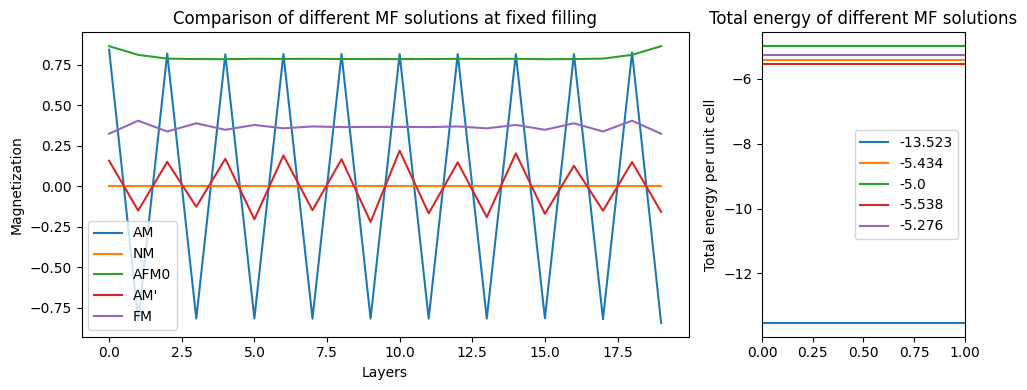

In [5]:
fix,axs = plt.subplots(1,2, figsize=(10,4), gridspec_kw={'width_ratios': [3, 1]})


etots = []

for j in range(len(MFstates)):
    #plot state
    if MFstates[j].param['mAF'].max() > MFstates[j].param['mF'].max():
        axs[0].plot(MFstates[j].param['mAF'],label=labels[j])
    else:
        axs[0].plot(MFstates[j].param['mF'],label=labels[j])
    
    #compute total energy
    e_tot = total_energy(MFstates[j], Lq=MF_parameters['Lq'])
    etots.append(e_tot)

    axs[1].plot([0,1], np.ones(2)*e_tot, label=np.round(e_tot, 3))

axs[0].set_xlabel('Layers')
axs[0].set_ylabel('Magnetization')
axs[0].set_title('Comparison of different MF solutions at fixed filling')
axs[0].legend()

axs[1].set_xlim(0,1)
axs[1].set_ylabel('Total energy per unit cell')
axs[1].set_title('Total energy of different MF solutions')
axs[1].legend()

plt.tight_layout()

print('Lowest energy state: ', labels[np.argmin(etots)])

# Properties of the state

## Checking properties of the bands

80
filling is:  0.509


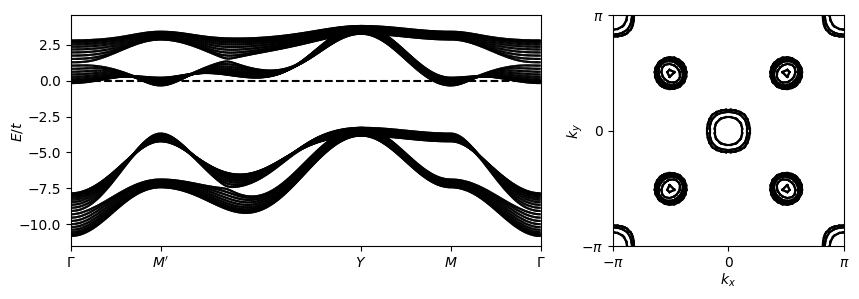

In [6]:

labels = ['\Gamma',"M'","Y","M",'\Gamma']
coloring_operator = H_DLKK.operator.spin
cmap = 'bwr'

print(H_DLKK.n_orbitals)

fig, [ax,ax1] = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3))
plot_bandstruc(ax,H_DLKK,labels_points_path=labels,coloring_operator=coloring_operator,cmap=cmap)
plot_FS(ax1,H_DLKK,coloring_operator=coloring_operator,cmap=cmap,Lk=50,print_filling=True)


In [7]:
Lq = MF_parameters['Lq'] #number of k-points in each direction

# Define the k-point grid
ks = sample_square(Lq)
#Diagonalize Hamiltonian
es,psis = H_DLKK.diagonalize(*ks)

def plot_spectral_density(ax,spectral_density,cmap='bwr',title_plot='',show_xlabel=True,show_ylabel=True,vmax='',vmin=''):
    """Plots colored spin spectral density on ax,

    cmap: a matplotlib colormap
    title_plot: title of the plot if given
    vmax: maximum value for color scaling
    """
    if title_plot!='':
         ax.set_title(title_plot,fontsize=6)
    ax.set_aspect('equal')
    if show_xlabel:
        ax.set_xlabel('$k_x$',labelpad=1)
        ax.set_xticks([-pi,0,pi])
        ax.set_xticklabels(['$-\pi$',0,'$\pi$'])
    else:
        ax.set_xticklabels([])
    if show_ylabel:
        ax.set_ylabel('$k_y$',labelpad=-2.5)
        ax.set_yticks([-pi,0,pi])
        ax.set_yticklabels(['$-\pi$',0,'$\pi$'])
    else:
        ax.set_yticklabels([])
    ax.set_xlim(-pi,pi)
    ax.set_ylim(-pi,pi)
    #--------------
    if vmax == '':
        vmax = np.abs(spectral_density).max()
    if vmin == '':
        vmin = -vmax
    im = ax.imshow(spectral_density,extent=(-pi,pi,-pi,pi),origin='lower',cmap=cmap,vmin=vmin,vmax=vmax)
    return im




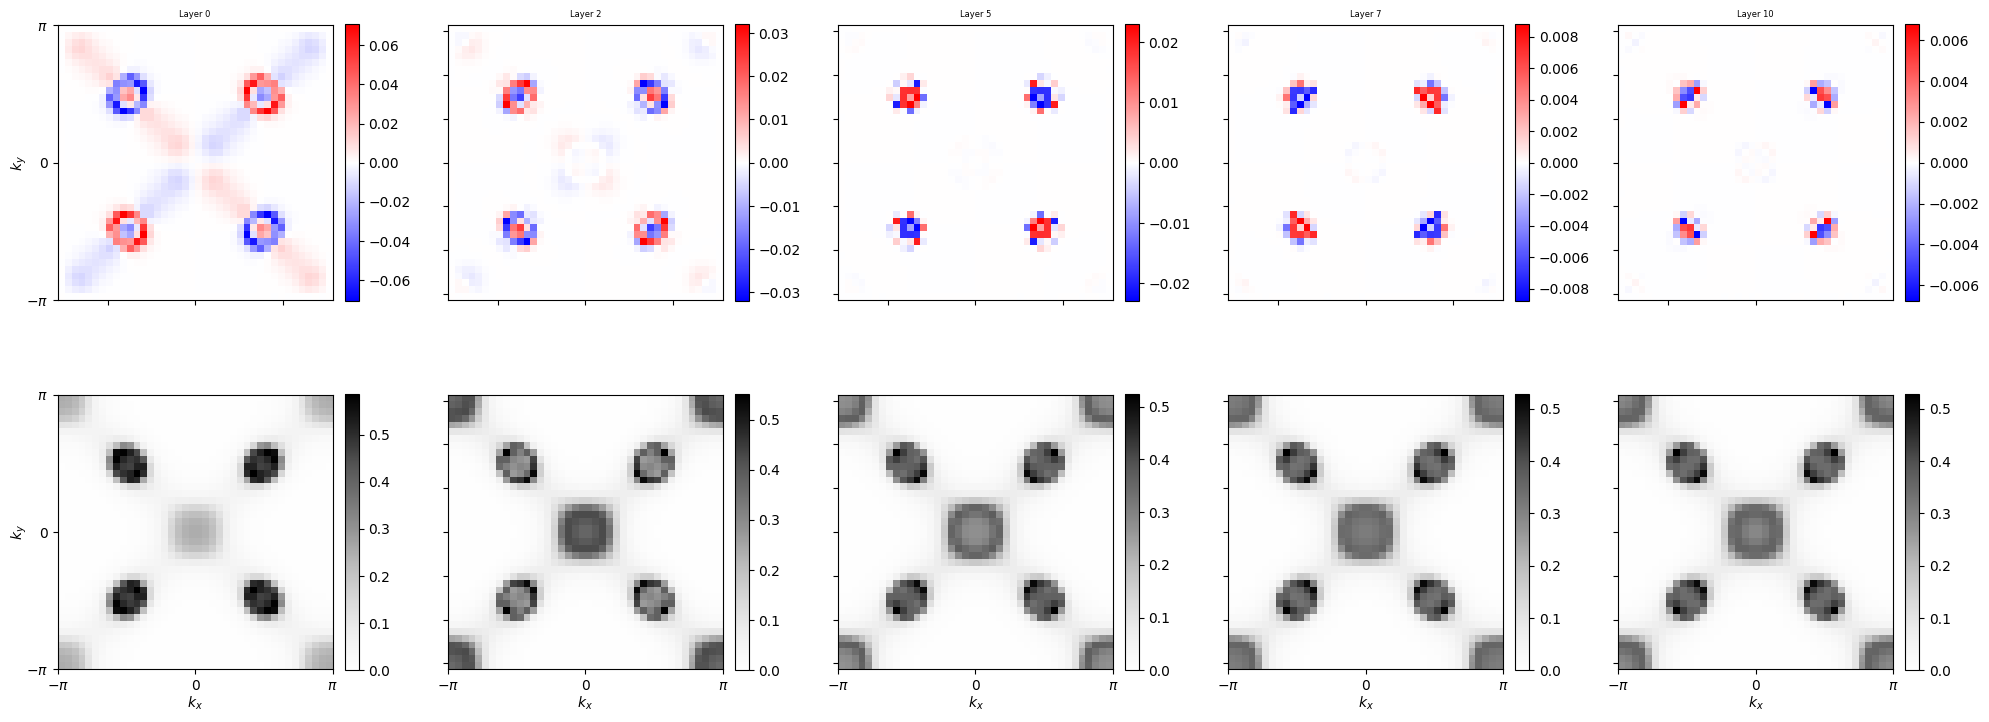

In [8]:
Gamma = 10e-2
len_z = Hparam0['len_z']
#layers = [0,len_z//6,len_z//3,len_z//2]
layers = np.linspace(0,len_z//2,5,dtype=int)


#Plot
fig,axs = plt.subplots(2,len(layers),figsize=(4*len(layers),8))

for ax_column,layer in zip(axs.T,layers):
    proj_2layers = projector2layer(layer,len_z=len_z)+projector2layer(layer+1,len_z=len_z)
    coloring_operator = np.kron(proj_2layers,H_DLKK.suboperator.spin) #projected spin_operator

    #compute spin spectral density
    Os = exp_value_O(coloring_operator,psis) #.shape=(n,y,x)
    spectral_density_spin = np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/len_z

    #compute spectral density
    Os = exp_value_O(np.kron(proj_2layers,np.ones(4)),psis) #.shape=(n,y,x)
    spectral_density0 = np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/len_z

    
    vmax_spin = np.abs(spectral_density_spin).max()
    vmax0 = np.abs(spectral_density0).max()

    imT = plot_spectral_density(ax_column[0],spectral_density_spin,title_plot='Layer '+str(layer),show_ylabel=(layer==0),show_xlabel=False,vmax=vmax_spin)
    imB = plot_spectral_density(ax_column[1],spectral_density0,show_ylabel=(layer==0),show_xlabel=True,vmax=vmax0,vmin=0,cmap='Greys')
    
    #colorbars for each plot
    plt.colorbar(imT,ax=ax_column[0],fraction=0.046,pad=0.04)
    plt.colorbar(imB,ax=ax_column[1],fraction=0.046,pad=0.04)    


# plt.colorbar(imT,ax=axs[0,-1],fraction=0.046,pad=0.04)
# plt.colorbar(imB,ax=axs[1,-1],fraction=0.046,pad=0.04)

plt.tight_layout()


## Checking the spectral density along a 1D path

In [9]:
Lq = 500 #number of k-points in each direction
Gamma = 1.e-3


# Define the k-point grid
kxs = np.linspace(0,pi/2,Lq)
kys = kxs
#Diagonalize Hamiltonian
es,psis = H_DLKK.diagonalize(kxs,kys)

#compute spectral density
#layers = np.arange(0,param['len_z']//2,1,dtype=int) #half the layers
layers = np.arange(0,Hparam0['len_z']-1,1,dtype=int) #all layers
spin_spec_dens = []
spec_dens = []
for layer in layers:
    proj_2layers = projector2layer(layer,len_z=len_z)+projector2layer(layer+1,len_z=Hparam0['len_z'])
    coloring_operator = np.kron(proj_2layers,H_DLKK.suboperator.spin) #projected spin_operator

    #compute spin spectral density
    Os = exp_value_O(coloring_operator,psis) #.shape=(n,y,x)
    spin_spec_dens.append(np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/len_z)

    #compute spectral density
    Os = exp_value_O(np.kron(proj_2layers,np.ones(4)),psis) #.shape=(n,y,x)
    spec_dens.append(np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/len_z)

spin_spec_dens = np.array(spin_spec_dens) #layers, ks
spec_dens = np.array(spec_dens)


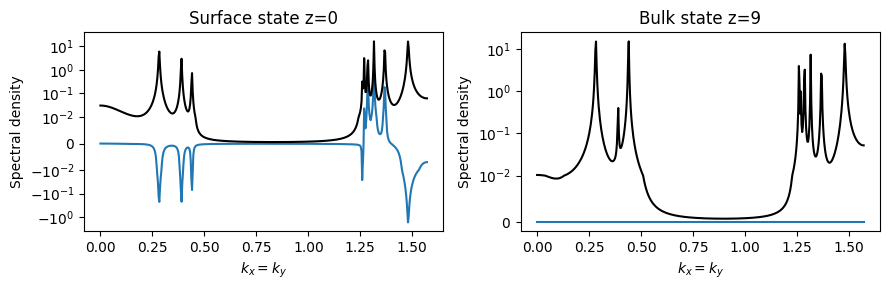

In [10]:
fig,axs = plt.subplots(1,2,figsize=(9,3))

layer = 0
axs[0].set_title('Surface state z=0')
axs[0].plot(kxs,spin_spec_dens[layer],'-')
axs[0].plot(kxs,spec_dens[layer],'k-')
axs[0].set_yscale('symlog',linthresh=1e-2)

layer = layers[-1]//2 if layers[-1]==len_z-2 else layers[-1]
axs[1].set_title('Bulk state z='+str(layer))
axs[1].plot(kxs,spin_spec_dens[layer],'-')
axs[1].plot(kxs,spec_dens[layer],'k-')
axs[1].set_yscale('symlog',linthresh=1e-2)

axs[0].set_xlabel('$k_x=k_y$')
axs[1].set_xlabel('$k_x=k_y$')
axs[0].set_ylabel('Spectral density')
axs[1].set_ylabel('Spectral density')

plt.tight_layout()


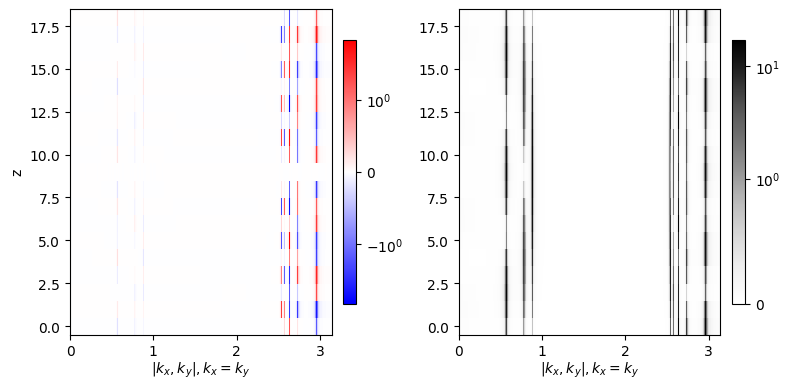

In [11]:
fig,[ax1,ax2] = plt.subplots(1,2,figsize=(8,4))

ax1.set_xlabel('$|k_x,k_y|, k_x=k_y$',labelpad=1)
ax2.set_xlabel('$|k_x,k_y|, k_x=k_y$',labelpad=1)
ax1.set_ylabel('z')

vmax = np.abs(spin_spec_dens).max()
#We use a symlog scale
#im1 = ax1.imshow(spin_spec_dens,extent=(0,pi,0,layers[-1]),origin='lower',cmap='bwr',vmin=-vmax,vmax=vmax,aspect='auto')
im1 = ax1.imshow(spin_spec_dens,extent=(0,pi,-0.5,layers[-1]+0.5),origin='lower',cmap='bwr',aspect='auto',interpolation='none',norm=matplotlib.colors.SymLogNorm(linthresh=1, linscale=1,vmin=-vmax, vmax=vmax, base=10))
#im2 = ax2.imshow(spec_dens,extent=(0,pi,0,layers[-1]),origin='lower',cmap='Greys',vmin=0,vmax=spec_dens.max(),aspect='auto')
im2 = ax2.imshow(spec_dens,extent=(0,pi,-0.5,layers[-1]+0.5),origin='lower',cmap='Greys',aspect='auto',interpolation='none',norm=matplotlib.colors.SymLogNorm(linthresh=1, linscale=1,vmin=0,vmax=spec_dens.max(), base=10))

plt.colorbar(im1,ax=ax1,fraction=0.046,pad=0.04)
plt.colorbar(im2,ax=ax2,fraction=0.046,pad=0.04)

plt.tight_layout()

The integrated spectral density along the path $(0,0)$ to $(\pi,\pi)$

$A_\sigma(z) = \int_{k=(0,0)}^{k=\pi/2(1,1)} A_\sigma(z,k)$

and as function of distance from the bulk, i.e.

$A_\sigma(d) = \int_{z'=0}^{z'=d} d z' \int_{k=(0,0)}^{k=\pi/2(1,1)} A_\sigma(L_z/2+z',k) $

Text(0.5, 0, 'depth d')

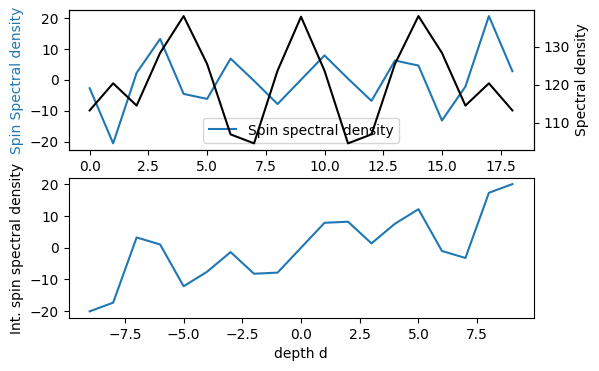

In [12]:
#integration along k
intk_spin_spec_dens = np.sum(spin_spec_dens,axis=1)
intk_spec_dens = np.sum(spec_dens,axis=1)

#integration from the middle to the surface
int_spin_spec_dens = np.concatenate((np.cumsum(intk_spin_spec_dens[layers[-1]//2::-1])[::-1],
                                     np.cumsum(intk_spin_spec_dens[layers[-1]//2::]   )))
# int_spec_dens = np.cumsum(np.sum(spec_dens,axis=1),axis=0)

fig,axs = plt.subplots(2,1,figsize=(6,4))
axs[0].plot(intk_spin_spec_dens,'-',label='Spin spectral density')
axs2 = axs[0].twinx()
axs2.plot(intk_spec_dens,'k-',label='spectral density')
axs[0].set_xlabel('Layer')
axs[0].set_ylabel('Spin Spectral density', color='C0')
axs2.set_ylabel('Spectral density', color='k')
axs[0].legend()

xs = np.concatenate((np.arange(-layers[-1]//2,1,1),np.arange(0,layers[-1]//2+1)))
axs[1].plot(xs,int_spin_spec_dens,'-',label='Integrated spectral density from middle to surface')
axs[1].set_ylabel('Int. spin spectral density')
axs[1].set_xlabel('depth d')

## Conductivity

In [13]:
#setting parameters
Lk = 40 #number of k-points in each direction

# Calculate spin conductivity
cond_tensor = conductivity_orbital_resolved(H_DLKK,Lk=Lk,optimize='path') #.shape=(localH,x,y)

In [14]:
#1) way of dealing with this tensor: smart reshaping and then contracting all unwanted indices
n_layers = 2 #sum always n_layers layers up
cond_tensor2 = np.reshape(cond_tensor,(len_z,2,2,2,2)) #.shape=(layer,spin,sublattice,x,y)
cond_tensor2 = cond_tensor2.reshape(-1,n_layers,2,2,2,2) #.shape=(layer/n_layers,n_layers,sublattice,spin,x,y)
cond_xx = np.sum(cond_tensor2[:,:,:,:,0,0],axis=(1,3)) #.shape=(layer/n_layers,spin)
spin_cond_xx = cond_xx[:,0]-cond_xx[:,1] #difference of spin indices
cond0_xx = cond_xx[:,0]+cond_xx[:,1] #total cond: sum of spin indices
#indices is fixed by n_layers
layers = np.arange(0,len_z+1-n_layers,n_layers)


# #2) way of dealing with this tensor: construct full observable and then contract (slower but does't matter)
# #we can compute pairs (0,1), (1,2), (2,3), ...
# spin_cond00 = []; cond00 = []
# layers = np.arange(0,param['len_z']-1,1) #specify 

# for layer in layers:
#     proj_2layers = projector2layer(layer,len_z=param['len_z'])+projector2layer(layer+1,len_z=param['len_z'])
#     Spin_op_layer = np.kron(proj_2layers,Spin_operator) #projected spin_operator
#     spin_cond00.append(np.sum(Spin_op_layer*cond_tensor[:,0,0]))
#     cond00.append(np.sum(np.kron(proj_2layers,np.ones(4))*cond_tensor[:,0,0]))

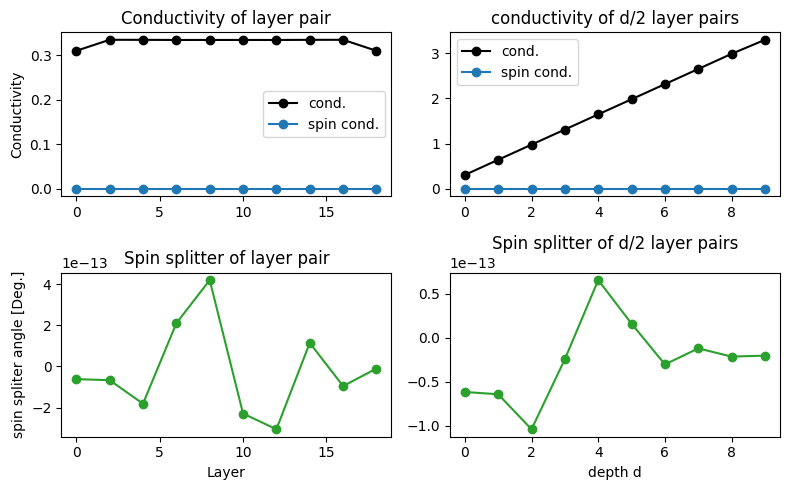

In [15]:
fig,axs = plt.subplots(2,2,figsize=(8,5))

#layer resolved
axs[0,0].set_title('Conductivity of layer pair')
axs[0,0].plot(layers,cond0_xx,'ko-',label='cond.')
axs[0,0].plot(layers,spin_cond_xx,'o-',label='spin cond.')
axs[0,0].set_ylabel('Conductivity')
axs[0,0].legend()

axs[1,0].set_title('Spin splitter of layer pair')
axs[1,0].plot(layers,2*np.arctan(spin_cond_xx/cond0_xx)*180/pi,'o-',color='C2')
axs[1,0].set_xlabel('Layer')
axs[1,0].set_ylabel('spin spliter angle [Deg.]')

#layer summed
lz2 = len_z//2
xs = np.arange(0,lz2)
axs[0,1].set_title('conductivity of d/2 layer pairs')
axs[0,1].plot(xs,np.cumsum(cond0_xx[:lz2]),'ko-',label='cond.')
axs[0,1].plot(xs,np.cumsum(spin_cond_xx[:lz2]),'o-',label='spin cond.')
axs[0,1].legend()

axs[1,1].set_title('Spin splitter of d/2 layer pairs')
axs[1,1].plot(xs,2*np.arctan(np.cumsum(spin_cond_xx[:lz2])/np.cumsum(cond0_xx[:lz2]))*180/pi,'o-',color='C2')
axs[1,1].set_xlabel('depth d')


plt.tight_layout()


(-3.141592653589793, 3.141592653589793)

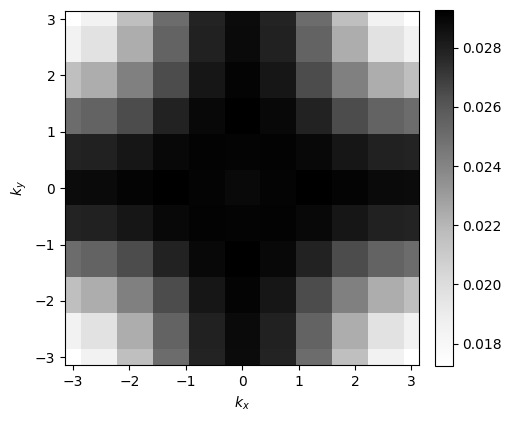

In [16]:

Lk=10

#V = np.kron(np.diag(projector2layer(0,len_z=len_z)),np.kron(sx,np.eye(2))) #ndarray.shape= (localH,localH)
V = np.diag(np.kron(projector2layer(0,len_z=len_z),np.ones(4))) #ndarray.shape= (localH,localH)

kmesh = sample_square(Lk) #we can also sample the small BZ and copy and paste
ldos = local_dos_QPI(H_DLKK,operator=V,kmesh=kmesh,return_symmetric_array=True)

fig, ax = plt.subplots(1,1,figsize=(5,5))

im = ax.imshow(ldos,origin='lower',cmap='Greys',extent=extent(Lk))
plt.colorbar(im,ax=ax,fraction=0.046,pad=0.04)
ax.set_xlabel('$k_x$')
ax.set_ylabel('$k_y$')
ax.set_xlim(-pi,pi)
ax.set_ylim(-pi,pi)

(-3.141592653589793, 3.141592653589793)

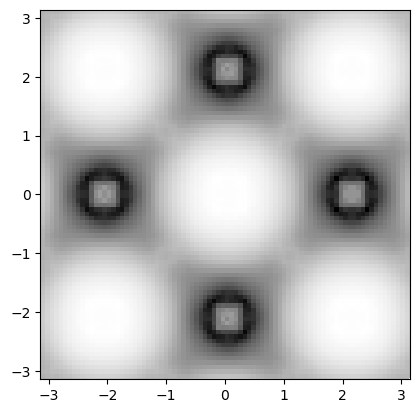

In [ ]:
from scipy.ndimage import rotate

data_rot45 = np.tile(ldos, (3, 3))
data_rot45 = rotate(data_rot45, 45, reshape=True, order=1, mode='constant', cval=np.nan)

rescale_factor = pi*1.5*2**0.5
rescale_factor = 2*pi
im = plt.imshow(data_rot45,extent=extent_from_data(data_rot45,-rescale_factor,rescale_factor,-rescale_factor,rescale_factor),origin='lower',cmap='Greys')
plt.xlim(-pi,pi)
plt.ylim(-pi,pi)
